# 0. Charge the dataset and libraries

In [1]:
import pandas as pd
import ijson
import matplotlib.pyplot as plt
import seaborn as sns
import re
import random

random.seed(2)

In [2]:
with open("train.json", "r", encoding="utf-8") as f:
    data = []
    for item in ijson.items(f, "item"):
        data.append(item)

random.shuffle(data)
data = data[:10000]

train = pd.DataFrame(data)

with open("test.json", "r", encoding="utf-8") as f:
    data = []
    for i, item in enumerate(ijson.items(f, "item")):
        data.append(item)
        
random.shuffle(data)
data = data[:10000]

test = pd.DataFrame(data)


with open("validation.json", "r", encoding="utf-8") as f:
    data = []
    for i, item in enumerate(ijson.items(f, "item")):
        data.append(item)

    random.shuffle(data)
    data = data[:10000]

validation = pd.DataFrame(data)



# Exploratory Data Analysis (EDA)

## INFORMATION ABOUT THE DATASET

In [3]:
print(f"Total of examples in train: {len(train)}")
print(f"Total of examples in validation: {len(validation)}")
print(f"Total of examples in test: {len(test)}")
print("")
print(f"Unique classes in train: {train['label'].unique()}")
print(f"Unique classes in validation: {validation['label'].unique()}")
print(f"Unique classes in test: {test['label'].unique()}")

Total of examples in train: 10000
Total of examples in validation: 10000
Total of examples in test: 10000

Unique classes in train: ['negative' 'positive' 'neutral']
Unique classes in validation: ['positive' 'neutral' 'negative']
Unique classes in test: ['negative' 'positive']


In [4]:
train = train[train['label'] != 'neutral']
validation = validation[validation['label'] != 'neutral']
test = test[test['label'] != 'neutral']

print("Each Class Distribution in Train:")
print(train['label'].value_counts())
print("\nEach Class Distribution in Validation:")
print(validation['label'].value_counts())
print("\nEach Class Distribution in Test:")
print(test['label'].value_counts())

Each Class Distribution in Train:
label
negative    5078
positive    4892
Name: count, dtype: int64

Each Class Distribution in Validation:
label
positive    3086
negative    2847
Name: count, dtype: int64

Each Class Distribution in Test:
label
negative    5009
positive    4991
Name: count, dtype: int64


In [5]:
pd.set_option('display.max_colwidth', None)

print("--- EJEMPLOS REALES EN TRAIN POR CLASE ---\n")
for clase in train['label'].unique():
    print(f"ETIQUETA: {clase}")
    muestras = train[train['label'] == clase]['text'].sample(3, random_state=42)
    
    for i, texto in enumerate(muestras, 1):
        print(f"{i}. {texto}")
    print("-" * 50)

--- EJEMPLOS REALES EN TRAIN POR CLASE ---

ETIQUETA: negative
1. the dutch royal family is doing well till now death people at our queensday a very sad day in dutch history
2. is bummed that it's overcast today! i was planning to lay out in the sun all day and enjoy my day off!
3. i wonder when and will have a real wedding on another note goodbye lc kristen sucks def boycotting the hills
--------------------------------------------------
ETIQUETA: positive
1. okay hehe just know i loves you tho
2. @prblog @steverubel posterous looks like tumblr for iPhone? looks interesting. can you fold this content .. http://tr.im/nhcv
3. sitting on the dock tanning with siblings wz swimming in lake n hour
--------------------------------------------------


In [6]:
print("--- EJEMPLOS REALES EN VALIDATION POR CLASE ---\n")
for clase in validation['label'].unique():
    print(f"ETIQUETA: {clase}")
    muestras = validation[validation['label'] == clase]['text'].sample(3, random_state=42)
    
    for i, texto in enumerate(muestras, 1):
        print(f"{i}. {texto}")
    print("-" * 50)


--- EJEMPLOS REALES EN VALIDATION POR CLASE ---

ETIQUETA: positive
1. assumes it wasnt so taboo to start an email with 'LOL' considering that the reply it got started with 'ROFL. PWN3D.' I love the internet!
2. Tell me about it! What is obvious in real life makes for great entertainment on TV  It is great to try and figure out the killer
3. 3 days of frisbee, three nights of partying and sprained ligaments. Can`t imagine a better long weekend
--------------------------------------------------
ETIQUETA: negative
1. favorite shirt ruined:death by bleach  #fb
2. Was talking to Vincent  Miss him so baadly.
3. cheeks bakery just closed  crazy how williamsburg can support an infinite # of boutiques w/bad clothes and not one decent place 4 a scone
--------------------------------------------------


In [7]:
print("--- EJEMPLOS REALES EN TEST POR CLASE ---\n")
for clase in test['label'].unique():
    print(f"ETIQUETA: {clase}")
    muestras = test[test['label'] == clase]['text'].sample(3, random_state=42)
    
    for i, texto in enumerate(muestras, 1):
        print(f"{i}. {texto}")
    print("-" * 50)

--- EJEMPLOS REALES EN TEST POR CLASE ---

ETIQUETA: negative
1. @LeahJKelly Maybe it's false info? If true, that really fucking sucks that they canceled your tour - I would be in tears.  I'm sorry.
2. on my way to work  this week I shall mostly be in London.
3. is going back to spend another night in hosp with daughter...
--------------------------------------------------
ETIQUETA: positive
1. first half of Amp6-Basic soldered!  | Now: espresso | Next: sort chemistry notes, Mikkelandersen.dk, django admin action - &amp; out sun park?
2. @SelimaCat i'll talk a little more about that in my blog... gives me good direction on what to write about!
3. is moving on. time to forget him. forever in my life~
--------------------------------------------------


## LANGUAGE

In [8]:
import fasttext
import plotly.express as px

# Load the pre-trained model
model = fasttext.load_model('lid.176.bin')

def is_english(text, threshold=0.8):
    # Remove newlines for better detection
    text = text.replace("\n", " ")
    prediction = model.predict(text, k=1)
    
    lang = prediction[0][0].replace('__label__', '')
    confidence = prediction[1][0]
    
    return lang == 'en' and confidence >= threshold

train['is_english'] = train['text'].apply(lambda x: is_english(x, threshold=0.9))
validation['is_english'] = validation['text'].apply(lambda x: is_english(x, threshold=0.9))
test['is_english'] = test['text'].apply(lambda x: is_english(x, threshold=0.9))

fig = px.histogram(train, x="is_english", title="Distribution of English vs Non-English in Train", text_auto=True)
fig.show()

fig = px.histogram(validation, x="is_english", title="Distribution of English vs Non-English in Validation", text_auto=True)
fig.show()

fig = px.histogram(test, x="is_english", title="Distribution of English vs Non-English in Test", text_auto=True)
fig.show()


mask_train = train['text'].apply(lambda x: is_english(x, threshold=0.9))
train = train[mask_train]

mask_validation = validation['text'].apply(lambda x: is_english(x, threshold=0.9))
validation = validation[mask_validation]

mask_test = test['text'].apply(lambda x: is_english(x, threshold=0.9))
test = test[mask_test]




## LENGTH OF TEXT

In [9]:
train['char_count'] = train['text'].str.len()
train['word_count'] = train['text'].apply(lambda x: len(str(x).split()))

fig_hist = px.histogram(train, 
                        x="word_count", 
                        nbins=50,
                        title="Distribución del Número de Palabras en Train",
                        labels={'word_count': 'Número de Palabras'},
                        color_discrete_sequence=['skyblue'])  

fig_hist.update_layout(template='plotly_white', bargap=0.1)
fig_hist.show()



fig_box = px.box(train, 
                 x="label",
                    y="word_count",
                    color="label",
                    points="outliers", # Muestra los puntos que se salen del rango normal
                    title="Comparativa de Longitud de Palabras por Clase en Train",
                    labels={'word_count': 'Palabras', 'label': 'Clase'},
                    color_discrete_sequence=px.colors.qualitative.Set2)
fig_box.update_layout(template='plotly_white', showlegend=False)
fig_box.show()

In [10]:
validation['char_count'] = validation['text'].str.len()
validation['word_count'] = validation['text'].apply(lambda x: len(str(x).split()))
print(validation[['char_count', 'word_count']].describe())

fig_hist = px.histogram(validation, 
                        x="word_count",
                        nbins=50,
                        title="Distribución del Número de Palabras en Validation",
                        labels={'word_count': 'Número de Palabras'},
                        color_discrete_sequence=['skyblue'])    
fig_hist.update_layout(template='plotly_white', bargap=0.1)
fig_hist.show()

fig_box = px.box(validation, 
                 x="label", 
                 y="word_count", 
                 color="label",
                 points="outliers", # Muestra los puntos que se salen del rango normal
                 title="Comparativa de Longitud de Palabras por Clase en Validation",
                 labels={'word_count': 'Palabras', 'label': 'Clase'},
                 color_discrete_sequence=px.colors.qualitative.Set2)

fig_box.update_layout(template='plotly_white', showlegend=False)
fig_box.show()

        char_count   word_count
count  3461.000000  3461.000000
mean     76.505923    14.865646
std      34.195913     6.691305
min       6.000000     1.000000
25%      48.000000     9.000000
50%      75.000000    15.000000
75%     106.000000    20.000000
max     138.000000    32.000000


In [11]:
test['char_count'] = test['text'].str.len()
test['word_count'] = test['text'].apply(lambda x: len(str(x).split()))
print(test[['char_count', 'word_count']].describe())

fig_hist = px.histogram(test, 
                        x="word_count", 
                        nbins=50,
                        title="Distribución del Número de Palabras en Test",
                        labels={'word_count': 'Número de Palabras'},
                        color_discrete_sequence=['skyblue'])
fig_hist.update_layout(template='plotly_white', bargap=0.1)
fig_hist.show()

fig_box = px.box(test, 
                 x="label", 
                 y="word_count", 
                 color="label",
                 points="outliers", # Muestra los puntos que se salen del rango normal
                 title="Comparativa de Longitud de Palabras por Clase en Test",
                 labels={'word_count': 'Palabras', 'label': 'Clase'},
                 color_discrete_sequence=px.colors.qualitative.Set2)
fig_box.update_layout(template='plotly_white', showlegend=False)
fig_box.show()

        char_count   word_count
count  5457.000000  5457.000000
mean     80.647059    15.087777
std      35.836031     6.845447
min       7.000000     1.000000
25%      51.000000    10.000000
50%      79.000000    15.000000
75%     112.000000    21.000000
max     158.000000    33.000000


## PRESENCE OF URLS HASHTAGS AND EMOTICONS

In [12]:
import plotly.express as px
import re

def count_urls(text):
    return len(re.findall(r'http[s]?://\S+|www\.\S+', str(text)))

train['url_count'] = train['text'].apply(count_urls)
train['has_url'] = (train['url_count'] > 0).astype(int)

validation['url_count'] = validation['text'].apply(count_urls)
validation['has_url'] = (validation['url_count'] > 0).astype(int)

test['url_count'] = test['text'].apply(count_urls)
test['has_url'] = (test['url_count'] > 0).astype(int)



In [13]:
train_plot = train.groupby('label')['has_url'].mean().reset_index()
train_plot['percentage'] = train_plot['has_url'] * 100
fig_train = px.bar(train_plot, 
                   x='label', 
                   y='percentage',
                   color='label',
                   labels={'percentage': 'Presencia de URLs (%)', 'label': 'Clase'},
                   title='Porcentaje de mensajes con URLs por Clase en Train',
                   text_auto='.2f')
fig_train.update_layout(
    xaxis_title="Clase",
    yaxis_title="% de mensajes con URL",
    showlegend=False,
    template='plotly_white'
)
fig_train.show()

In [14]:
validation_plot = validation.groupby('label')['has_url'].mean().reset_index()
validation_plot['percentage'] = validation_plot['has_url'] * 100
fig_validation = px.bar(validation_plot, 
                   x='label', 
                   y='percentage',
                   color='label',
                   labels={'percentage': 'Presencia de URLs (%)', 'label': 'Clase'},
                   title='Porcentaje de mensajes con URLs por Clase en Validation',
                   text_auto='.2f') 
fig_validation.update_layout(
    xaxis_title="Clase",
    yaxis_title="% de mensajes con URL",
    showlegend=False,
    template='plotly_white'
)
fig_validation.show()   

In [15]:
test_plot = test.groupby('label')['has_url'].mean().reset_index()
test_plot['percentage'] = test_plot['has_url'] * 100
fig_test = px.bar(test_plot, 
                   x='label', 
                   y='percentage',
                   color='label',
                   labels={'percentage': 'Presencia de URLs (%)', 'label': 'Clase'},
                   title='Porcentaje de mensajes con URLs por Clase en Test',
                   text_auto='.2f')
fig_test.update_layout(
    xaxis_title="Clase",
    yaxis_title="% de mensajes con URL",
    showlegend=False,
    template='plotly_white'
)   
fig_test.show()

In [16]:
train['hastag_count'] = train['text'].apply(lambda x: len(re.findall(r'#\w+', str(x))))
train['has_hashtag'] = (train['hastag_count'] > 0).astype(int)

validation['hastag_count'] = validation['text'].apply(lambda x: len(re.findall(r'#\w+', str(x))))
validation['has_hashtag'] = (validation['hastag_count'] > 0).astype(int)

test['hastag_count'] = test['text'].apply(lambda x: len(re.findall(r'#\w+', str(x))))
test['has_hashtag'] = (test['hastag_count'] > 0).astype(int)

all_hashtags_train = re.findall(r'#\w+', " ".join(train['text'].astype(str)))

all_hashtags_validation = re.findall(r'#\w+', " ".join(validation['text'].astype(str)))

all_hashtags_test = re.findall(r'#\w+', " ".join(test['text'].astype(str)))


In [17]:
import plotly.express as px

train['mention_count'] = train['text'].apply(lambda x: len(re.findall(r'@\w+', str(x))))
train['has_mention'] = (train['mention_count'] > 0).astype(int)
                                                           
validation['mention_count'] = validation['text'].apply(lambda x: len(re.findall(r'@\w+', str(x))))
validation['has_mention'] = (validation['mention_count'] > 0).astype(int)
                                                                     
test['mention_count'] = test['text'].apply(lambda x: len(re.findall(r'@\w+', str(x))))
test['has_mention'] = (test['mention_count'] > 0).astype(int)

In [18]:
train_plot = train.groupby('label')['has_mention'].mean().reset_index()
train_plot['percentage'] = train_plot['has_mention'] * 100
fig_train = px.bar(train_plot, x='label', y='percentage', title='Training Data: Mention Percentage by Label',text_auto='.1f')
fig_train.update_layout(
    xaxis_title="Clase",
    yaxis_title="% de mensajes con Menciones",
    showlegend=False,
    template='plotly_white'
)
fig_train.show()

validation_plot = validation.groupby('label')['has_mention'].mean().reset_index()
validation_plot['percentage'] = validation_plot['has_mention'] * 100
fig_validation = px.bar(validation_plot, x='label', y='percentage', title='Validation Data: Mention Percentage by Label',text_auto='.1f')
fig_validation.update_layout(
    xaxis_title="Clase",
    yaxis_title="% de mensajes con Menciones",
    showlegend=False,
    template='plotly_white'
)
fig_validation.show()

test_plot = test.groupby('label')['has_mention'].mean().reset_index()
test_plot['percentage'] = test_plot['has_mention'] * 100
fig_test = px.bar(test_plot, x='label', y='percentage', title='Test Data: Mention Percentage by Label',text_auto='.1f')
fig_test.update_layout(
    xaxis_title="Clase",
    yaxis_title="% de mensajes con Menciones",
    showlegend=False,
    template='plotly_white'
)
fig_test.show()

In [19]:
import re

def eliminar_menciones(text):
    return re.sub(r'@\w+', '', text)

train['text'] = train['text'].apply(eliminar_menciones)
validation['text'] = validation['text'].apply(eliminar_menciones)
test['text'] = test['text'].apply(eliminar_menciones)

In [20]:
import plotly.express as px

df_hashtags_train = train.groupby('label')['has_hashtag'].mean().reset_index()
df_hashtags_train['percentage'] = df_hashtags_train['has_hashtag'] * 100
fig_train_hashtags = px.bar(df_hashtags_train, 
                      x='label', 
                      y='percentage',
                      color='label',
                      text_auto='.1f',
                      labels={'percentage': 'Presencia de Hashtags (%)', 'label': 'Clase'},
                      title='Porcentaje de uso de Hashtags por Clase en Train',
                      color_discrete_sequence=px.colors.qualitative.Safe)

fig_train_hashtags.update_layout(
    yaxis_title="% de mensajes con Hashtags",
    template='plotly_white',
    showlegend=False
)
fig_train_hashtags.show()

In [21]:
df_hashtags_validation = validation.groupby('label')['has_hashtag'].mean().reset_index()
df_hashtags_validation['percentage'] = df_hashtags_validation['has_hashtag'] * 100
fig_validation_hashtags = px.bar(df_hashtags_validation, 
                      x='label', 
                      y='percentage',
                      color='label',
                      text_auto='.1f',
                      labels={'percentage': 'Presencia de Hashtags (%)', 'label': 'Clase'},
                      title='Porcentaje de uso de Hashtags por Clase en Validation',
                      color_discrete_sequence=px.colors.qualitative.Safe)

fig_validation_hashtags.update_layout(
    yaxis_title="% de mensajes con Hashtags",
    template='plotly_white',
    showlegend=False
)

fig_validation_hashtags.show()

In [22]:
df_hashtags_test = test.groupby('label')['has_hashtag'].mean().reset_index()
df_hashtags_test['percentage'] = df_hashtags_test['has_hashtag'] * 100
fig_test_hashtags = px.bar(df_hashtags_test, 
                      x='label', 
                      y='percentage',
                      color='label',
                      text_auto='.1f',
                      labels={'percentage': 'Presencia de Hashtags (%)', 'label': 'Clase'},
                      title='Porcentaje de uso de Hashtags por Clase en Test',
                      color_discrete_sequence=px.colors.qualitative.Safe)

fig_test_hashtags.update_layout(
    yaxis_title="% de mensajes con Hashtags",
    template='plotly_white',
    showlegend=False
)
fig_test_hashtags.show()

In [23]:
import emoji

# Función robusta para contar emojis reales
def contar_emojis_reales(text):
    if not isinstance(text, str):
        return 0
    # emoji.emoji_count cuenta específicamente pictogramas Unicode de la base de datos oficial
    return emoji.emoji_count(text)

train['emoji_count'] = train['text'].apply(contar_emojis_reales)
train['has_emoji'] = (train['emoji_count'] > 0).astype(int)

validation['emoji_count'] = validation['text'].apply(contar_emojis_reales)
validation['has_emoji'] = (validation['emoji_count'] > 0).astype(int)                                   

test['emoji_count'] = test['text'].apply(contar_emojis_reales)
test['has_emoji'] = (test['emoji_count'] > 0).astype(int)

total_con_emoji_train = train['has_emoji'].sum()
print(f"Total de mensajes con emojis detectados en Train: {total_con_emoji_train}")

total_con_emoji_validation = validation['has_emoji'].sum()
print(f"Total de mensajes con emojis detectados en Validation: {total_con_emoji_validation}")

total_con_emoji_test = test['has_emoji'].sum()
print(f"Total de mensajes con emojis detectados en Test: {total_con_emoji_test}")


test = test[test['has_emoji'] != 1]

print(f"Total emojis en Test después de filtrado: {test['has_emoji'].sum()}")






Total de mensajes con emojis detectados en Train: 0
Total de mensajes con emojis detectados en Validation: 0
Total de mensajes con emojis detectados en Test: 1
Total emojis en Test después de filtrado: 0


## POSIBLE DUPLICATES

In [24]:
print(f"Duplicate texts in Train: {train.duplicated(subset=['text']).sum()}")
print(f"Duplicate texts in Validation: {validation.duplicated(subset=['text']).sum()}")
print(f"Duplicate texts in Test: {test.duplicated(subset=['text']).sum()}")

Duplicate texts in Train: 0
Duplicate texts in Validation: 1
Duplicate texts in Test: 1


In [25]:
drop_duplicates_train = train.drop_duplicates(subset=['text'])
drop_duplicates_validation = validation.drop_duplicates(subset=['text'])
drop_duplicates_test = test.drop_duplicates(subset=['text'])

In [26]:
# Unir todos los datasets
joined = pd.concat(
    [
        train.assign(dataset="train"),
        validation.assign(dataset="validation"),
        test.assign(dataset="test")
    ],
    ignore_index=True
)

print(f"Duplicate texts in combined dataset: {joined.duplicated(subset=['text']).sum()}")

# Eliminar duplicados globales por texto
joined = joined.drop_duplicates(subset=["text"]).reset_index(drop=True)

# Separar otra vez
train = joined[joined["dataset"] == "train"].drop(columns="dataset").reset_index(drop=True)

validation = joined[joined["dataset"] == "validation"].drop(columns="dataset").reset_index(drop=True)

test = joined[joined["dataset"] == "test"].drop(columns="dataset").reset_index(drop=True)

# Comprobar tamaños
print("Train:", train.shape)
print("Validation:", validation.shape)
print("Test:", test.shape)

Duplicate texts in combined dataset: 40
Train: (5880, 14)
Validation: (3452, 14)
Test: (5425, 14)


## Posible empty or extremely short texts

In [27]:
print(f"Empty texts in Train: {train['text'].isna().sum()}")
print(f"Empty texts in Validation: {validation['text'].isna().sum()}")
print(f"Empty texts in Test: {test['text'].isna().sum()}")

Empty texts in Train: 0
Empty texts in Validation: 0
Empty texts in Test: 0


## Words or Tokens Frequent by Class

In [28]:
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd

def get_top_n_words(corpus, n=10, language='spanish'): # Cambiado a spanish por defecto
    # 1. Limpieza básica: quitar nulos y asegurar que sean strings
    corpus = corpus.dropna().astype(str)
    
    # Si el corpus está vacío tras la limpieza, devolvemos lista vacía para no romper el bucle
    if corpus.empty or (corpus.str.strip() == "").all():
        return []

    try:
        # 2. Configuramos el vectorizador
        # Nota: 'spanish' requiere que tengas stop words de sklearn o nltk
        vec = CountVectorizer(stop_words=language).fit(corpus)
        
        bag_of_words = vec.transform(corpus)
        sum_words = bag_of_words.sum(axis=0) 
        
        words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
        return sorted(words_freq, key = lambda x: x[1], reverse=True)[:n]
    
    except ValueError:
        # Si aun así falla (porque solo hay stop words), devolvemos lista vacía
        return []


label
negative    8049
positive    6708
Name: count, dtype: int64
Positive words: 97273
Negative words: 119809


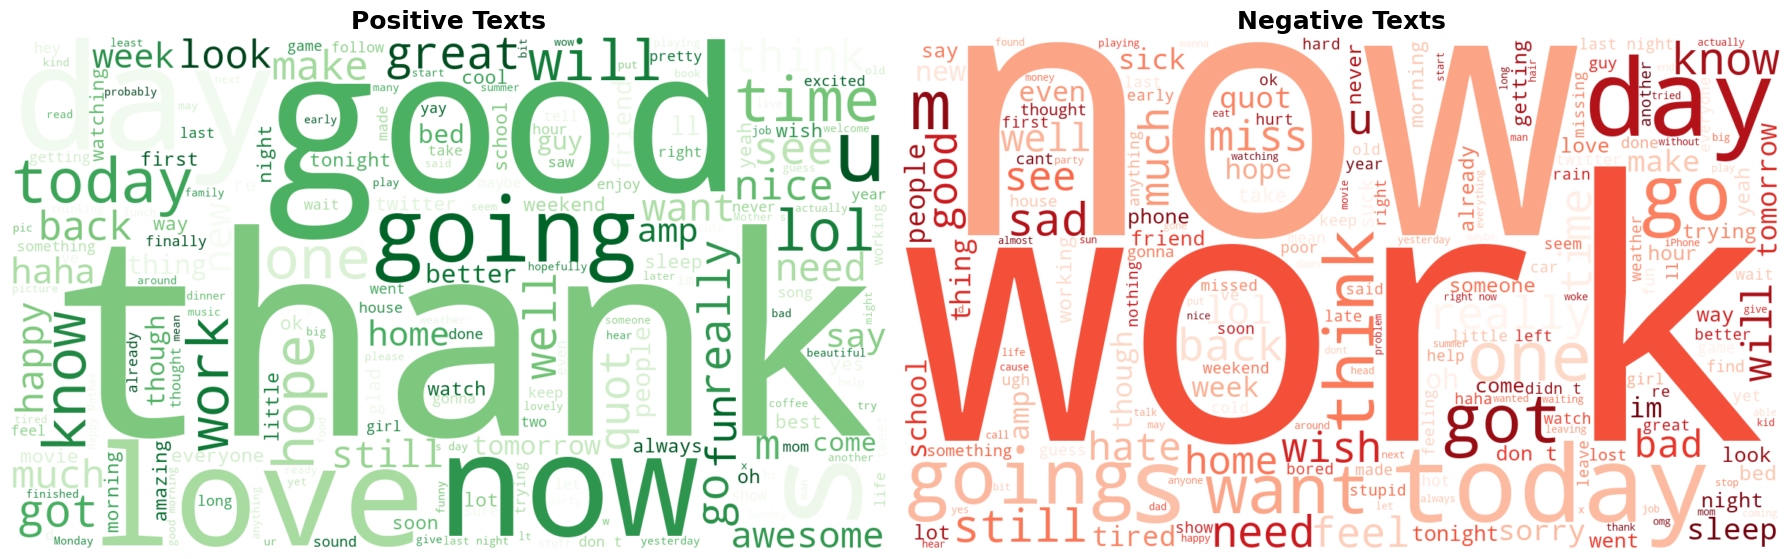

In [29]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import pandas as pd

# Unir datasets
joined = pd.concat(
    [train, validation, test],
    ignore_index=True
)

# Ver etiquetas reales
print(joined["label"].value_counts())

# CAMBIA ESTO según lo que te salga arriba
positive_label = "positive"
negative_label = "negative"

# Si tus labels son 1 y 0, usa:
# positive_label = 1
# negative_label = 0

positive_text = " ".join(
    joined[joined["label"] == positive_label]["text"]
    .dropna()
    .astype(str)
)

negative_text = " ".join(
    joined[joined["label"] == negative_label]["text"]
    .dropna()
    .astype(str)
)

print("Positive words:", len(positive_text.split()))
print("Negative words:", len(negative_text.split()))

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

if len(positive_text.split()) > 0:
    wc_positive = WordCloud(
        width=1200,
        height=700,
        background_color="white",
        colormap="Greens"
    ).generate(positive_text)

    axes[0].imshow(wc_positive, interpolation="bilinear")
    axes[0].set_title("Positive Texts", fontsize=18, fontweight="bold")
    axes[0].axis("off")
else:
    axes[0].text(0.5, 0.5, "No positive texts found", ha="center", va="center")
    axes[0].axis("off")

if len(negative_text.split()) > 0:
    wc_negative = WordCloud(
        width=1200,
        height=700,
        background_color="white",
        colormap="Reds"
    ).generate(negative_text)

    axes[1].imshow(wc_negative, interpolation="bilinear")
    axes[1].set_title("Negative Texts", fontsize=18, fontweight="bold")
    axes[1].axis("off")
else:
    axes[1].text(0.5, 0.5, "No negative texts found", ha="center", va="center")
    axes[1].axis("off")

plt.tight_layout()
plt.show()

In [30]:
import plotly.express as px


# 1. Definir una lista de palabras que quieres ignorar porque salen en todas las clases
# Agrégalas aquí según lo que veas en tus resultados actuales
extra_stop_words = ['just', 'like', 'get', 'go', 'would', 'make', 'one']

def plot_top_words_by_class(df, label_value, title_color):
    # Filtrar por clase
    text_clase = df[df['label'] == label_value]['text']
    
    # Obtener top words (Asegúrate de usar 'spanish' si tus textos son en español)
    # Combinamos las stop words de sklearn con las nuestras
    from sklearn.feature_extraction import text
    stop_words = list(text.ENGLISH_STOP_WORDS.union(extra_stop_words))
    
    top_words = get_top_n_words(text_clase, n=15, language=stop_words)
    
    if not top_words:
        print(f"No hay datos suficientes para la clase {label_value}")
        return
    
    # Crear DataFrame para el gráfico
    df_temp = pd.DataFrame(top_words, columns=['Palabra', 'Frecuencia'])
    df_temp = df_temp.sort_values(by='Frecuencia', ascending=True) # Para que la más alta esté arriba
    
    # Crear gráfico
    fig = px.bar(df_temp, 
                 x='Frecuencia', 
                 y='Palabra', 
                 orientation='h',
                 title=f'Top 15 Palabras - Categoría: {label_value}',
                 color_discrete_sequence=[title_color],
                 template='plotly_white')
    
    fig.update_layout(height=500, width=800, yaxis={'categoryorder':'total ascending'})
    fig.show()

# 2. Ejecutar un gráfico para cada categoría
# Ajusta los nombres/números de las etiquetas según tu dataset
colores = ['#EF553B', '#636EFA', '#00CC96'] # Rojo para negativo, Azul para neutral, Verde para positivo


In [31]:
for i, label in enumerate(sorted(train['label'].unique())):
    color = colores[i] if i < len(colores) else '#AB63FA'
    plot_top_words_by_class(train, label, color)    

In [32]:
for i, label in enumerate(sorted(validation['label'].unique())):
    color = colores[i] if i < len(colores) else '#AB63FA'
    plot_top_words_by_class(validation, label, color)

In [33]:
for i, label in enumerate(sorted(test['label'].unique())):
    color = colores[i] if i < len(colores) else '#AB63FA'
    plot_top_words_by_class(test, label, color)

## Posible Problems of Ambiguous Labeling

In [34]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Usamos TF-IDF para ver qué palabras son "importantes" en cada clase
tfidf = TfidfVectorizer(stop_words='english', max_features=100)
# Agrupamos todo el texto por clase
class_texts_train = train.groupby('label')['text'].apply(lambda x: " ".join(x.astype(str)))
tfidf_matrix_train = tfidf.fit_transform(class_texts_train)
words_train = tfidf.get_feature_names_out()

print("Palabras compartidas con alto peso en múltiples clases en Train:")
# (Este análisis te dirá si 'bad' sale como top en Neutral y en Negative al mismo tiempo)
print(set(words_train))


class_texts_validation = validation.groupby('label')['text'].apply(lambda x: " ".join(x.astype(str)))
tfidf_matrix_validation = tfidf.fit_transform(class_texts_validation)
words_validation = tfidf.get_feature_names_out()

print("Palabras compartidas con alto peso en múltiples clases en Validation:")
# (Este análisis te dirá si 'bad' sale como top en Neutral y en Negative al mismo tiempo)
print(set(words_validation))


class_texts_test = test.groupby('label')['text'].apply(lambda x: " ".join(x.astype(str)))
tfidf_matrix_test = tfidf.fit_transform(class_texts_test)
words_test = tfidf.get_feature_names_out()

print("Palabras compartidas con alto peso en múltiples clases en Test:")
# (Este análisis te dirá si 'bad' sale como top en Neutral y en Negative al mismo tiempo)
print(set(words_test))

Palabras compartidas con alto peso en múltiples clases en Train:
{'bed', 'friends', 'guess', 'getting', 'time', 'better', 've', 'won', 'just', 'days', 'looking', 'look', 'big', 'house', 'little', 'hours', 'having', 'make', 'night', 'went', 'oh', 'weekend', 'happy', 'things', 'sleep', 'thought', 'morning', 'im', 'tired', 'got', 'thing', 'gonna', 'ok', 'wish', 'feel', 'watch', 'new', 'early', 'great', 'think', 'didn', 'nice', 'pretty', 'doing', 'sorry', 'come', 'thanks', 'right', 'good', 'going', 'need', 'miss', 'school', 'yeah', 'day', 'watching', 'work', 'movie', 'long', 'lol', 'love', 'guys', 'hate', 'quot', 'tonight', 'tomorrow', 'amp', 'lot', 'finally', 'today', 'wait', 'people', 'fun', 'bad', 'like', 'phone', 'twitter', 'did', 'sick', 'want', 'really', 'don', 'way', 'let', 'say', 'yes', 'working', 'hope', 'soon', 'haha', 'awesome', 'll', 'best', 'yesterday', 'sad', 'week', 'weather', 'trying', 'know', 'home'}
Palabras compartidas con alto peso en múltiples clases en Validation:
{'b

Palabras importantes compartidas:
just        0.350654
good        0.225747
day         0.221344
like        0.219857
going       0.194014
work        0.184397
today       0.182311
really      0.159211
got         0.147740
time        0.147122
know        0.141391
don         0.139757
think       0.133992
ll          0.114803
love        0.113920
lol         0.113608
want        0.108753
night       0.101600
home        0.100006
hope        0.099527
quot        0.094865
need        0.090043
new         0.084962
oh          0.083368
wish        0.082432
did         0.076421
ve          0.076089
tomorrow    0.073425
sleep       0.072542
amp         0.068271
dtype: float64


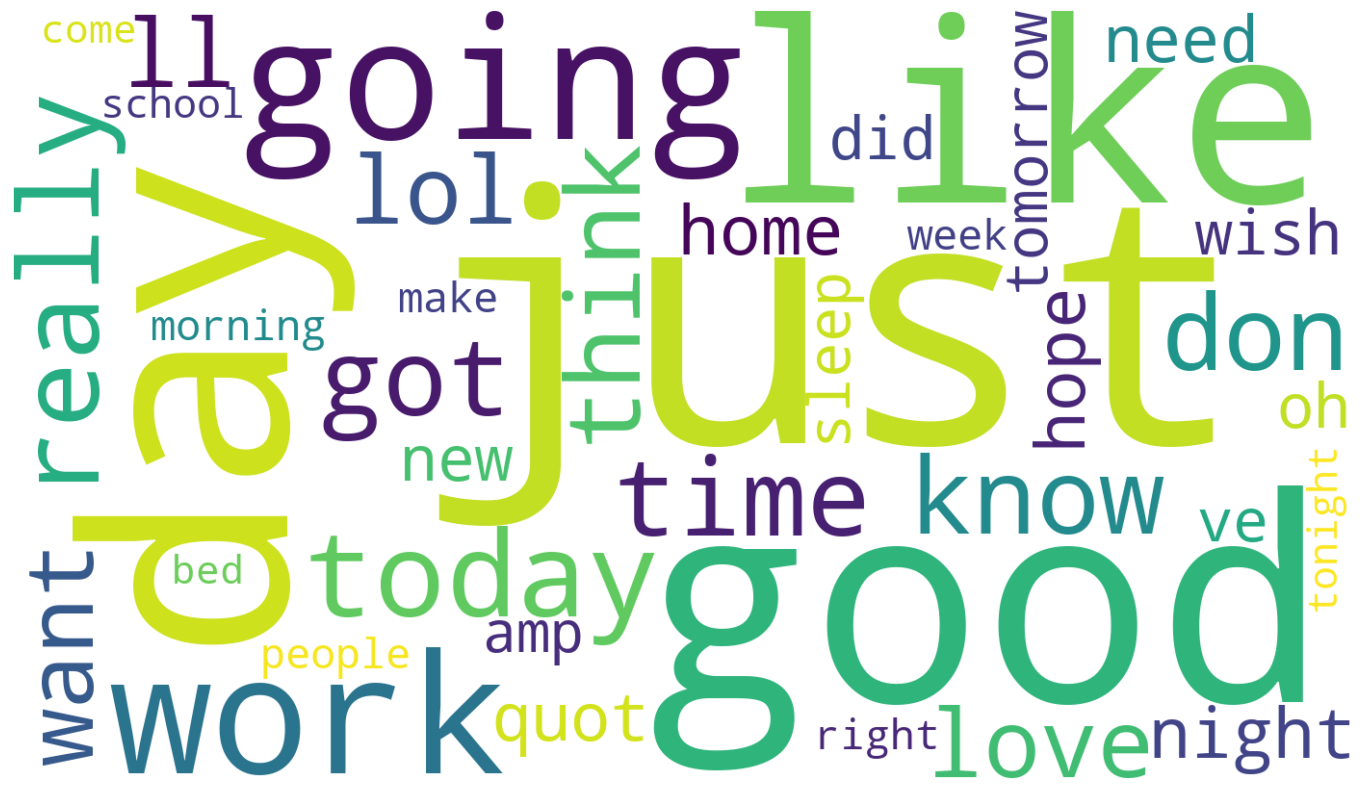

In [35]:
from sklearn.feature_extraction.text import TfidfVectorizer
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import pandas as pd

# =========================
# 1. Juntar los 3 datasets
# =========================
joined = pd.concat(
    [train, validation, test],
    ignore_index=True
)

joined = joined.dropna(subset=["text", "label"])
joined["text"] = joined["text"].astype(str)

# =========================
# 2. Agrupar textos por clase
# =========================
class_texts = joined.groupby("label")["text"].apply(lambda x: " ".join(x))

# =========================
# 3. Calcular TF-IDF por clase
# =========================
tfidf = TfidfVectorizer(
    stop_words="english",
    max_features=300
)

tfidf_matrix = tfidf.fit_transform(class_texts)

df_tfidf = pd.DataFrame(
    tfidf_matrix.toarray(),
    index=class_texts.index,
    columns=tfidf.get_feature_names_out()
)

# =========================
# 4. Palabras importantes compartidas
# =========================
threshold = 0.05  # puedes subirlo o bajarlo

shared_words = df_tfidf.columns[
    (df_tfidf > threshold).sum(axis=0) >= 2
]

# Peso medio de esas palabras
shared_scores = df_tfidf[shared_words].mean(axis=0).sort_values(ascending=False)

print("Palabras importantes compartidas:")
print(shared_scores.head(30))

# =========================
# 5. WordCloud
# =========================
wordcloud = WordCloud(
    width=1400,
    height=800,
    background_color="white",
    colormap="viridis"
).generate_from_frequencies(shared_scores.to_dict())

plt.figure(figsize=(14, 8))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.tight_layout()
plt.show()

In [36]:
ambiguos_train = train[train['word_count'].between(3, 8)].sample(10)
for i, row in ambiguos_train.iterrows():
    print(f"Texto: {row['text']} | Etiqueta actual: {row['label']}")


Texto: it will be controversial as hell | Etiqueta actual: positive
Texto: kobe and my lakers going for game | Etiqueta actual: positive
Texto: and that s all that matters | Etiqueta actual: positive
Texto: follow he might give you money go magic | Etiqueta actual: positive
Texto: : wish you were here too | Etiqueta actual: negative
Texto: had a pretty chill day | Etiqueta actual: positive
Texto:  my audition went beautifully | Etiqueta actual: positive
Texto: is not looking forward to work tomorrow | Etiqueta actual: negative
Texto: missin my family | Etiqueta actual: negative
Texto: on my way to the mall! | Etiqueta actual: positive


In [37]:
ambiguos_validation = validation[validation['word_count'].between(3, 8)].sample(10)
for i, row in ambiguos_validation.iterrows():
    print(f"Texto: {row['text']} | Etiqueta actual: {row['label']}")

Texto: is wishing she would get more followers | Etiqueta actual: positive
Texto: I guess you are not interested !! | Etiqueta actual: negative
Texto: aww that is sad | Etiqueta actual: negative
Texto: Hangin with the fam! My head is hurtin | Etiqueta actual: negative
Texto: i had a really good day today | Etiqueta actual: positive
Texto: Thanks, none close to me. | Etiqueta actual: positive
Texto: Thanks for getting me bottled water. | Etiqueta actual: positive
Texto: that`s bad luck! | Etiqueta actual: negative
Texto: hurt. done trying.. | Etiqueta actual: negative
Texto: loves the nice weather and 7:30 exams | Etiqueta actual: positive


In [38]:
ambiguos_test = test[test['word_count'].between(3, 8)].sample(10)
for i, row in ambiguos_test.iterrows():
    print(f"Texto: {row['text']} | Etiqueta actual: {row['label']}")

Texto:  I agree. I think he really does! | Etiqueta actual: negative
Texto:  You just have to watch it!!! | Etiqueta actual: negative
Texto: Bought it for PS3.. it has an install.. | Etiqueta actual: negative
Texto: think the closest one is in ohio... | Etiqueta actual: negative
Texto:  u have a very vorpal apartment. | Etiqueta actual: positive
Texto:  any woman you'd like to sing for? | Etiqueta actual: positive
Texto:  i'll try not to break anything | Etiqueta actual: positive
Texto: Did I submit my #squarespace today? Did now | Etiqueta actual: positive
Texto: fun soccer game today. we shoulda won tho | Etiqueta actual: negative
Texto: really nice artist list #GH5 | Etiqueta actual: positive


## DISTRIBUTION OF CLASSES

In [39]:
import plotly.express as px

# TRAIN
fig = px.histogram(
    train,
    x='label',
    title='Distribution of Classes in Train',
    text_auto=True
)

fig.update_traces(textposition='inside')
fig.show()

print(train['label'].value_counts(normalize=True))


# VALIDATION
fig = px.histogram(
    validation,
    x='label',
    title='Distribution of Classes in Validation',
    text_auto=True
)

fig.update_traces(textposition='inside')
fig.show()

print(validation['label'].value_counts(normalize=True))


# TEST
fig = px.histogram(
    test,
    x='label',
    title='Distribution of Classes in Test',
    text_auto=True
)

fig.update_traces(textposition='inside')
fig.show()

print(test['label'].value_counts(normalize=True))


label
negative    0.555272
positive    0.444728
Name: proportion, dtype: float64


label
positive    0.50029
negative    0.49971
Name: proportion, dtype: float64


label
negative    0.563871
positive    0.436129
Name: proportion, dtype: float64


In [42]:
import nltk

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\jorge\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\jorge\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\jorge\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\jorge\AppData\Roaming\nltk_data...


True

In [43]:
import nltk
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

# descargar recursos (solo la primera vez)
nltk.download('punkt')
nltk.download('wordnet')

lemmatizer = WordNetLemmatizer()

def lemmatize_text(text):
    words = word_tokenize(text)
    lemmatized_words = [lemmatizer.lemmatize(word) for word in words]
    return " ".join(lemmatized_words)

train['text'] = train['text'].apply(lemmatize_text)
validation['text'] = validation['text'].apply(lemmatize_text)
test['text'] = test['text'].apply(lemmatize_text)

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\jorge\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\jorge\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


# 4. Análisis del problema y decisiones de preprocesamiento


## 4.1 Tipos de ruido en los textos

Los textos procedentes de redes sociales presentan un alto nivel de ruido debido a su naturaleza informal. Entre los elementos más habituales se encuentran:

- URLs (enlaces externos)
- Menciones a usuarios (`@usuario`)
- Hashtags (`#tema`)
- Emojis
- Abreviaturas (por ejemplo: "q", "xq", "lol")
- Errores ortográficos
- Repeticiones de caracteres (por ejemplo: "buenoooo", "noooo")
- Uso excesivo de mayúsculas

Este tipo de contenido dificulta el procesamiento automático del lenguaje natural y requiere una fase de preprocesamiento cuidadosa.

---

## 4.2 Elementos irrelevantes e informativos

No todos los elementos considerados "ruido" deben eliminarse. Es importante distinguir entre:

### Elementos generalmente irrelevantes
- URLs, que no aportan información semántica directa.
- Menciones a usuarios, que suelen ser contextuales y poco relevantes.

### Elementos potencialmente informativos
- Emojis, que transmiten emociones de forma explícita.
- Hashtags, que pueden resumir el tema del mensaje.
- Repeticiones de caracteres, que indican intensidad.
- Uso de mayúsculas, que puede reflejar énfasis.

Por tanto, el preprocesamiento debe equilibrar la limpieza del texto con la conservación de información relevante.

---

## 4.3 Tratamiento de emojis

Los emojis constituyen una fuente directa de información emocional. Su eliminación puede provocar una pérdida significativa de información, especialmente en tareas de análisis de sentimiento.

Se recomienda:
- Mantenerlos en el texto, o
- Transformarlos en representaciones textuales equivalentes.

---

## 4.4 Tratamiento de hashtags

Los hashtags pueden aportar información relevante sobre el contenido del mensaje.

Estrategias posibles:
- Eliminar únicamente el símbolo `#` y conservar la palabra (por ejemplo, `#happy` → `happy`).
- Analizar su impacto en el rendimiento del modelo.

---

## 4.5 Menciones, URLs y signos de puntuación

- **URLs**: se recomienda eliminarlas, ya que no aportan contenido útil.
- **Menciones**: generalmente eliminadas por su baja relevancia semántica.
- **Signos de puntuación**:
  - Algunos pueden aportar información (por ejemplo, "!!!" indica énfasis).
  - Se recomienda simplificar su uso en lugar de eliminarlos completamente.

---

## 4.6 Mayúsculas, repeticiones y abreviaturas

- **Mayúsculas**: pueden indicar énfasis o emoción, aunque habitualmente se normalizan a minúsculas.
- **Repeticiones de caracteres**: reflejan intensidad emocional (por ejemplo, "soooo good").
  - Se recomienda normalizarlas (por ejemplo, "sooo" → "soo" o "so").
- **Abreviaturas**: pueden dificultar la comprensión del modelo, especialmente en enfoques clásicos.

---

## 4.7 Rendimiento de modelos clásicos

Los modelos clásicos de aprendizaje automático, como:

- Regresión logística
- Máquinas de soporte vectorial (SVM)

combinados con técnicas como TF-IDF, ofrecen resultados competitivos en tareas de clasificación de texto.

Sus principales ventajas son:
- Baja complejidad computacional
- Alta interpretabilidad
- Buen rendimiento como línea base

---

## 4.8 Uso de redes neuronales

Las redes neuronales permiten capturar relaciones más complejas en los datos y, en muchos casos, mejoran el rendimiento respecto a los modelos clásicos.

No obstante, presentan algunas desventajas:
- Mayor coste computacional
- Necesidad de ajuste de hiperparámetros
- Menor interpretabilidad

---

## 4.9 Modelos preentrenados

Los modelos preentrenados (por ejemplo, BERT o RoBERTa) han demostrado un rendimiento superior en tareas de procesamiento del lenguaje natural.

Ventajas:
- Capturan mejor el contexto del lenguaje
- Manejan adecuadamente el lenguaje informal
- Ofrecen mejores métricas de evaluación (accuracy, F1-score)

---

## 4.10 Uso de modelos LLM en zero-shot

Los modelos de lenguaje de gran tamaño (LLM) permiten realizar tareas de clasificación sin entrenamiento específico mediante técnicas zero-shot.

Ventajas:
- No requieren datos etiquetados
- Fácil implementación

Limitaciones:
- Mayor coste computacional
- Menor control sobre el comportamiento
- Variabilidad en los resultados

---

## 4.11 Recomendación final

La elección del modelo depende de los requisitos del problema:

- **Precisión**: modelos preentrenados
- **Velocidad**: modelos clásicos
- **Coste computacional**: modelos clásicos
- **Interpretabilidad**: modelos clásicos
- **Facilidad de uso**: modelos LLM en zero-shot

En conclusión, los modelos clásicos constituyen una excelente línea base, mientras que los modelos preentrenados ofrecen el mejor rendimiento a costa de una mayor complejidad.